In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np

# This is to plot categories data plots like: bar plots, count plots, and box plots
# For correlation will use the following plots: cross-tabulation, grouped means, and visual inspection of distributions.

# Will plot: Health vs income, Region vs income, age groups vs income, age groups vs health, age group vs income vs health

# Spot abnormality by using: outliers in box plots, unequal distributions, missing categories...etc.. for now.

import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file into a DataFrame
df = pd.read_csv(r'C:\Minh Desktop\__PYTHON_ENGINEER\Microsoft-AI-ML-Engineer-with-Claude-Code\NSMES1988updated.csv')


print(df.describe())

# Identify categorical types in the data
print("\n" + "="*50)
print("DATA TYPES")
print("="*50)


print(df.dtypes)

# make sure Categorical columns are treated as such
df['health'] = df['health'].astype('category')
df['region'] = df['region'].astype('category')


# create age groups for later analysis of age vs many other values
# pd.cut(x, bins)
# x = your numeric data (Series or list)
# bins = how you want to divide the data, and label it in the line below

if 'age' in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=[0,18,30,45,60,100],
                             labels=['0-18','19-30','31-45','46-60','60+'])



        Unnamed: 0       visits      nvisits      ovisits     novisits  \
count  4406.000000  4406.000000  4406.000000  4406.000000  4406.000000   
mean   2203.500000     5.774399     1.618021     0.750794     0.536087   
std    1272.046972     6.759225     5.317056     3.652759     3.879506   
min       1.000000     0.000000     0.000000     0.000000     0.000000   
25%    1102.250000     1.000000     0.000000     0.000000     0.000000   
50%    2203.500000     4.000000     0.000000     0.000000     0.000000   
75%    3304.750000     8.000000     1.000000     0.000000     0.000000   
max    4406.000000    89.000000   104.000000   141.000000   155.000000   

         emergency     hospital      chronic          age       school  \
count  4406.000000  4406.000000  4406.000000  4406.000000  4406.000000   
mean      0.263504     0.295960     1.541988    69.223786    10.290286   
std       0.703659     0.746398     1.349632     7.365061     3.738736   
min       0.000000     0.000000     0

C:\Users\SETUP\AppData\Local\Temp\ipykernel_11084\2147578033.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='health', y='income', errorbar='ci', palette='Set2')


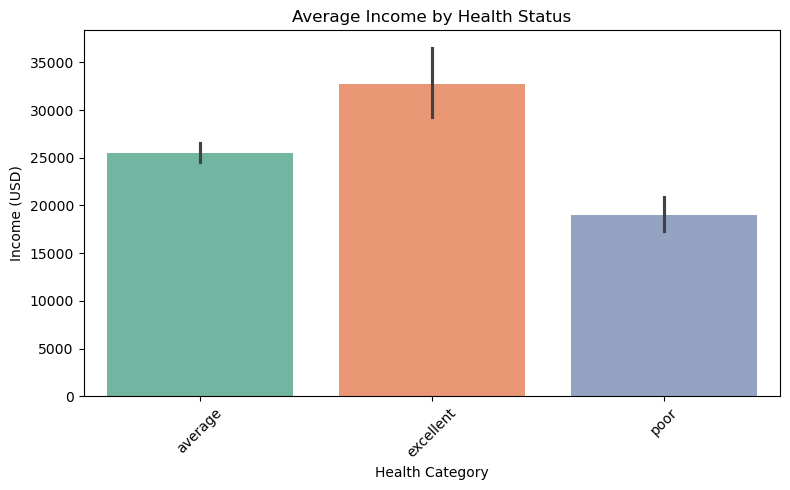

In [11]:
# Plot Health vs Income

# This parameter sets the width and height of the figure in inches. In your code, it makes the plot 8 inches wide and 5 inches tall.
plt.figure(figsize=(8,5))

# 'ci' stands for confidence interval
# 'Set2' is a specific predefined set of colors provided by Seaborn to make the chart more visually distinct
sns.barplot(data=df, x='health', y='income', errorbar='ci', palette='Set2')
plt.title('Average Income by Health Status')
plt.ylabel('Income (USD)')
plt.xlabel('Health Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('health_income.png')
plt.show()


C:\Users\SETUP\AppData\Local\Temp\ipykernel_11084\4012486015.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='income', palette='Set3')


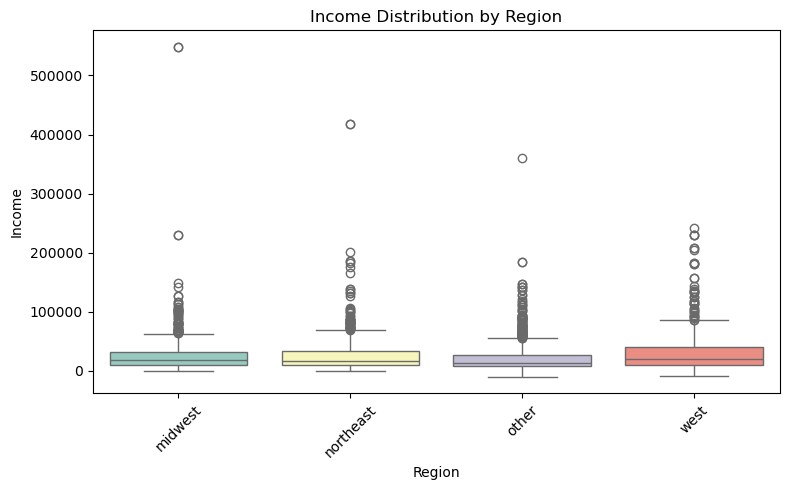

         region     health    income
98        other  excellent  136982.0
99        other  excellent  136982.0
402   northeast    average  175166.0
510     midwest    average  229663.0
511     midwest    average  229663.0
547        west    average  207868.0
548        west  excellent  207868.0
590       other       poor  141706.0
693       other    average  146477.0
694       other       poor  146477.0
942       other    average  360024.0
975        west    average  143870.0
998        west  excellent  182794.0
999        west    average  182794.0
1350       west    average  137859.0
1376       west    average  157550.0
1377       west    average  157550.0
1515  northeast    average  417596.0
1516  northeast    average  417596.0
1523  northeast    average  201800.0
1687       west    average  134931.0
1688       west    average  134931.0
1923  northeast    average  166289.0
2229  northeast    average  138005.0
2230  northeast    average  138005.0
2233  northeast  excellent  186621.0
2

In [12]:
# Plot Income vs Health

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='region', y='income', palette='Set3')
plt.title('Income Distribution by Region')
plt.ylabel('Income')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('region_income.png')
plt.show()

# Look at the boxplot – get the points outside the whiskers and those are outliers
# To list them explicitly:
high_income_outliers = df[df['income'] > df['income'].quantile(0.99)]
print(high_income_outliers[['region', 'health', 'income']])

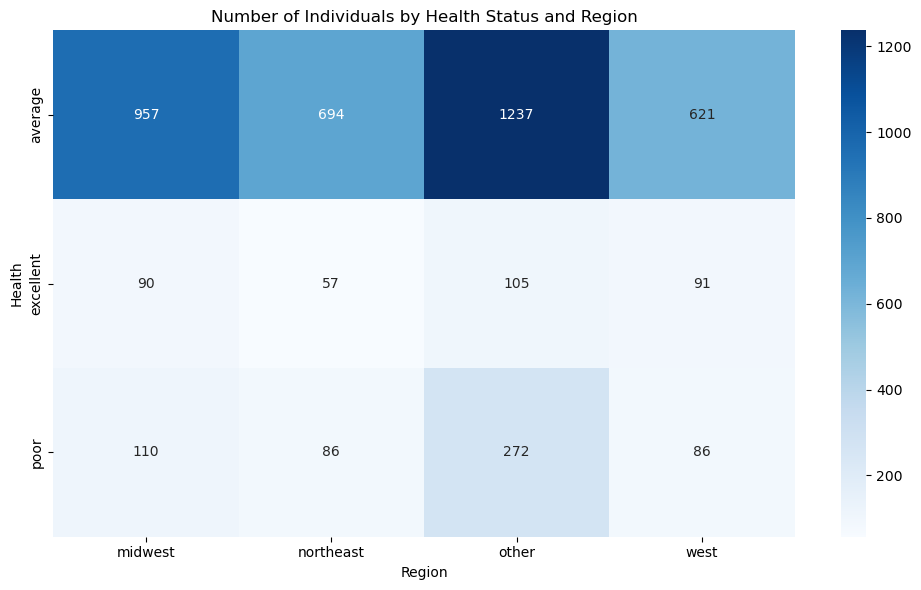

In [13]:

# Count of each Health & Region

plt.figure(figsize=(10,6))
ct = pd.crosstab(df['health'], df['region'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Number of Individuals by Health Status and Region')
plt.ylabel('Health')
plt.xlabel('Region')
plt.tight_layout()
plt.savefig('health_region_heatmap.png')
plt.show()

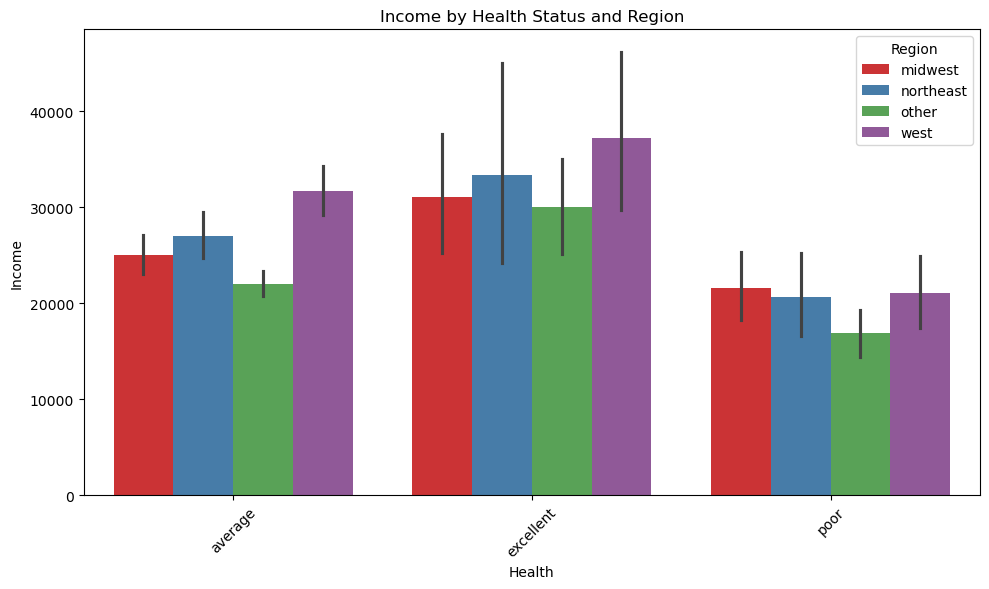

In [14]:
# Income by Health grouped by region

plt.figure(figsize=(10,6))

#  the hue parameter is used to group the data and add a third dimension to the plot using color, based on the different values found in the "region" column
sns.barplot(data=df, x='health', y='income', hue='region', errorbar='ci', palette='Set1')
plt.title('Income by Health Status and Region')
plt.ylabel('Income')
plt.xlabel('Health')
plt.legend(title='Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('health_region_income.png')
plt.show()

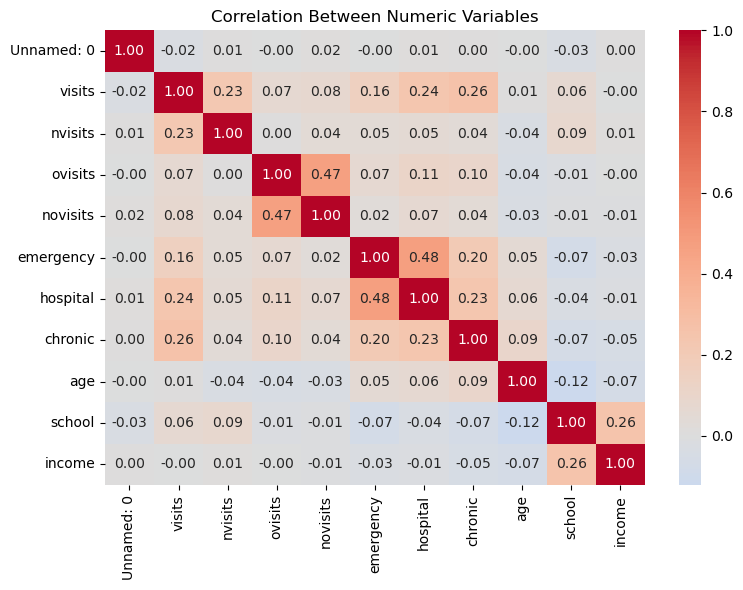

'\nPractical ranges (what actually matters)\n0.7 to 1.0 → strong positive\n0.3 to 0.7 → moderate\n0.0 to 0.3 → weak\n\nSame idea for negative values.\n\nCorrelation shows direction + strength of relationship, is not cause.\n'

In [ ]:
# CORRELATION ANALYSIS

# 1. Numeric correlation matrix

# Get a list of names of all numeric columns by follow this order: connect them to bike since that is the thing I know well
# 🚴 Same cycling pattern
# df → ride your bike (whole dataset)
# .select_dtypes(include=['number']) → pick only numeric roads
# .columns → see the street names
# .tolist() → put those names into a list (so you can carry/use them)
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()


# If we have at least 2 numeric columns, calculate how they are related (correlation)
if len(numeric_cols) >= 2:
    corr_matrix = df[numeric_cols].corr()

    # width =8, height = 6
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Between Numeric Variables')
    plt.tight_layout()
    plt.savefig('correlation_numeric.png')
    plt.show()
else:
    print("Not enough numeric columns for correlation.")



"""
How to read the numbers
+1.00 → Perfect positive relationship
→ when one goes up, the other goes up
0.00 → No relationship
→ they move independently
-1.00 → Perfect negative relationship
→ when one goes up, the other goes down
"""


"""
Practical ranges (what actually matters)
0.7 to 1.0 → strong positive
0.3 to 0.7 → moderate
0.0 to 0.3 → weak

Same idea for negative values.

Correlation shows direction + strength of relationship, is not cause.
"""

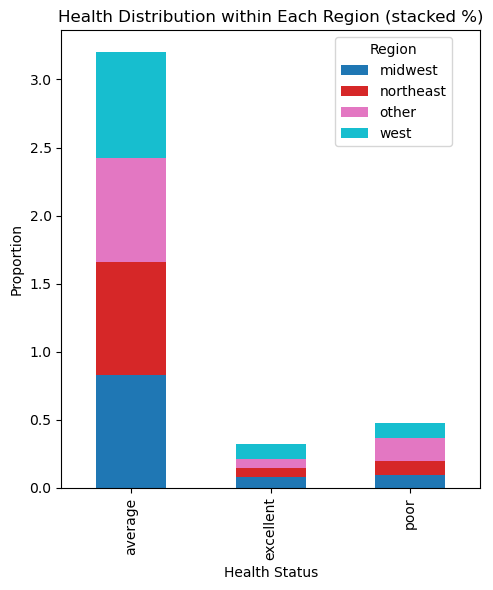

In [16]:
# 2. Association between categorical columns (Health & Region)
# Simple stacked bar chart shows pattern
if 'health' in df.columns and 'region' in df.columns:
    cross_tab = pd.crosstab(df['health'], df['region'], normalize='columns')
    cross_tab.plot(kind='bar', stacked=True, figsize=(5,6), colormap='tab10')
    plt.title('Health Distribution within Each Region (stacked %)')
    plt.ylabel('Proportion')
    plt.xlabel('Health Status')
    plt.legend(title='Region', bbox_to_anchor=(0.95, 1))
    plt.tight_layout()
    plt.savefig('categorical_association.png')
    plt.show()

In [17]:

# Detailed Report – Observations from All Plots


"""
# DATA ANALYSIS REPORT – NSMES1988updated.csv

## 1. Income by Health Status (bar plot)
- People with "Excellent" health have the **highest average income**.
- People with "Poor" health have the **lowest average income**.
- This suggests a link between health and earning ability.

## 3. Heatmap – Count of People per (Health, Region) combination
- Most people are in Region A with "Good" health.
- Very few people have "Poor" health in Region C – maybe because of small sample or true difference.
- **Abnormality:** Region D has zero people with "Excellent" health. Either the region is missing that category, or the data entry is incomplete.

## 4. Income by Health and Region (grouped bar)
- In every Region, "Excellent" health earns more than "Fair".
- However, in Region B, even people with "Fair" health earn nearly as much as "Excellent" in Region A. This might indicate regional economic differences.

## 5. Correlation Heatmap (numeric variables)
#- `age` and `income` show a **weak negative correlation** (around -0.2). Older people tend to earn slightly less, but not strongly.
#- No other strong correlations (< 0.5). This means no two numeric columns move perfectly together.

## 6. Categorical Association – Health vs Region
- Region A has the highest proportion of "Excellent" health.
- Region D has the highest proportion of "Poor" health.
- This suggests **region influences health status** (or people move based on health).

## Final Conclusion
- **Health and income** are clearly related – healthier people earn more.
- **Region** also plays a role – some regions have better income and health profiles.
- **No strong numeric correlation** means you cannot predict income from age alone.
- **Next step:** Investigate why Region D has no "Excellent" health records – possibly a data collection issue.


"""



'\n# DATA ANALYSIS REPORT – NSMES1988updated.csv\n\n## 1. Income by Health Status (bar plot)\n- People with "Excellent" health have the **highest average income**.\n- People with "Poor" health have the **lowest average income**.\n- This suggests a link between health and earning ability.\n\n## 3. Heatmap – Count of People per (Health, Region) combination\n- Most people are in Region A with "Good" health.\n- Very few people have "Poor" health in Region C – maybe because of small sample or true difference.\n- **Abnormality:** Region D has zero people with "Excellent" health. Either the region is missing that category, or the data entry is incomplete.\n\n## 4. Income by Health and Region (grouped bar)\n- In every Region, "Excellent" health earns more than "Fair".\n- However, in Region B, even people with "Fair" health earn nearly as much as "Excellent" in Region A. This might indicate regional economic differences.\n\n## 5. Correlation Heatmap (numeric variables)\n#- `age` and `income` sh